In [1]:


using BeautyContest
using StellarTracks, BolometricCorrections, InitialMassFunctions
using TypedTables: Table,FlexTable
using Unitful,UnitfulAstro,UnitfulAngles
using Korg
using LinearInterpolations
using AstroFITS, OIFITS
using Parameters
using AxisArrays
using Serialization
using Measurements
using LinearAlgebra
using CSV
using Dates


In [2]:
using Plots
gr();
cd(pkgdir(BeautyContest))

In [3]:
# declare instrument
inst = Instrument()


Instrument
  R: Int64 500
  fov: Quantity{Float64, NoDims, Unitful.FreeUnits{(mas,), NoDims, nothing}}
  fiber_fwhm: Quantity{Float64, NoDims, Unitful.FreeUnits{(mas,), NoDims, nothing}}
  Atel: Quantity{Float64, 𝐋², Unitful.FreeUnits{(m²,), 𝐋², nothing}}
  Ttel: Float64 0.28
  Tfiber: Float64 0.8
  Tgrism: Array{Float64}((233,)) [0.20004895961474578, 0.2577205319745585, 0.31481380343145543, 0.36596061407963315, 0.40765523600628306, 0.4376440977442779, 0.4568721064891666, 0.46739418030194985, 0.47428643690845695, 0.48041534168375055  …  0.1276221955538788, 0.1264837922245892, 0.12482339619257675, 0.12314611960585474, 0.12148344024889524, 0.11965095453833582, 0.11763323078870254, 0.11569799927445606, 0.11372833157211959, 0.11137538059706623]
  Δλ: Quantity{Float64, 𝐋, Unitful.FreeUnits{(nm,), 𝐋, nothing}}
  SR: Float64 0.67
  DIT: Quantity{Int64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}
  NDIT: Int64 4
  QE: Float64 0.81
  bkg_param: Array{Float64}((233, 4)) [1.970000147819519 37.2670654

# Globular Cluster Simulation

In [4]:
@with_kw struct Object
	distance= 5_000 # distance in parsec
	Age = 11e9 # Age in year
	mh = -0.75 # metalicity 
	
	
	Av = 3.1*0.04 # reddening
	μ = 5*log10(distance) - 5 # distance modulus 
	
	N = 15 # number of stars
end

obj = Object()
@unpack_Object obj;


In [5]:
gcname = "output/IIContest2026-GlobularCluster/GlobularClusterSimulation_2026-02-11T18:22:45.007.csv"
stars_table=CSV.read(gcname,Table; delim=",\t")

Table with 6 columns and 15 rows:
      mass      Kmag     logTe    logg     x_pos     y_pos
    ┌─────────────────────────────────────────────────────────
 1  │ 0.107077  22.6067  3.46888  5.24626  -13.9598  -35.3893
 2  │ 0.1103    22.5395  3.47366  5.23703  -37.2737  15.6888
 3  │ 0.11213   22.5013  3.47635  5.23175  7.24546   -13.9539
 4  │ 0.122355  22.2862  3.48979  5.20355  -40.1894  1.06611
 5  │ 0.160401  21.6948  3.51879  5.12989  -37.7336  -48.264
 6  │ 0.187291  21.3715  3.53045  5.08916  29.4791   34.1652
 7  │ 0.227258  20.9537  3.54394  5.03577  22.3681   -34.1045
 8  │ 0.280308  20.5306  3.55468  4.98073  -11.4153  0.0582139
 9  │ 0.35034   20.0588  3.56789  4.91868  -14.5746  5.38577
 10 │ 0.418381  19.5682  3.58675  4.84456  12.6995   15.0348
 11 │ 0.484974  19.0876  3.61211  4.77621  40.4766   -20.5864
 12 │ 0.562049  18.5308  3.65872  4.70757  -30.9297  -47.8423
 13 │ 0.60797   18.2022  3.68657  4.66707  -18.2149  -25.8528
 14 │ 0.666019  17.8844  3.72296  4.62331  

## Compute spectra of each star

┌ Warning: The provided linelist was not empty, but none of the lines were within the provided wavelength range.
└ @ Korg /Users/ferreol/.julia/packages/Korg/vUJeO/src/synthesize.jl:338
┌ Warning: The provided linelist was not empty, but none of the lines were within the provided wavelength range.
└ @ Korg /Users/ferreol/.julia/packages/Korg/vUJeO/src/synthesize.jl:338
┌ Warning: The provided linelist was not empty, but none of the lines were within the provided wavelength range.
└ @ Korg /Users/ferreol/.julia/packages/Korg/vUJeO/src/synthesize.jl:338
┌ Warning: The provided linelist was not empty, but none of the lines were within the provided wavelength range.
└ @ Korg /Users/ferreol/.julia/packages/Korg/vUJeO/src/synthesize.jl:338
┌ Warning: The provided linelist was not empty, but none of the lines were within the provided wavelength range.
└ @ Korg /Users/ferreol/.julia/packages/Korg/vUJeO/src/synthesize.jl:338
┌ Warning: The provided linelist was not empty, but none of the lines 

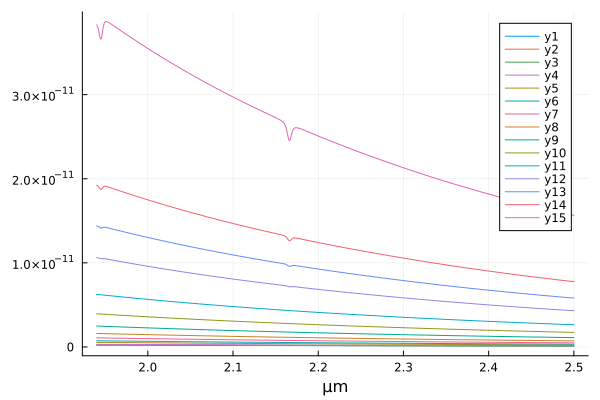

In [7]:
flux = Vector{Vector{Float64}}(undef,N)
cntm = Vector{Vector{Float64}}(undef,N)
λs = []
for (i, (_, Kmag, logTe, logg,_,_)) ∈ enumerate(stars_table)
	λs, flux[i], cntm[i] = synth(; M_H=mh, Teff=10^(logTe), logg= logg,wavelengths=(19400, 25000,1), rectify=false, R=inst.R)	
	flux[i] = flux[i] ./ sum(flux[i]) .* 10^(-Kmag / 2.5) 
end
λs= upreferred.(λs .* 0.1u"nm");
plot(λs.|>u"μm" ,flux,ticks=:native)

## Compute total magnitude

In [8]:

Kmag = -2.5*log10(sum(10 .^(-stars_table.Kmag ./ 2.5) ))

16.080087832648783

##  attenuation due to the fiber lobe

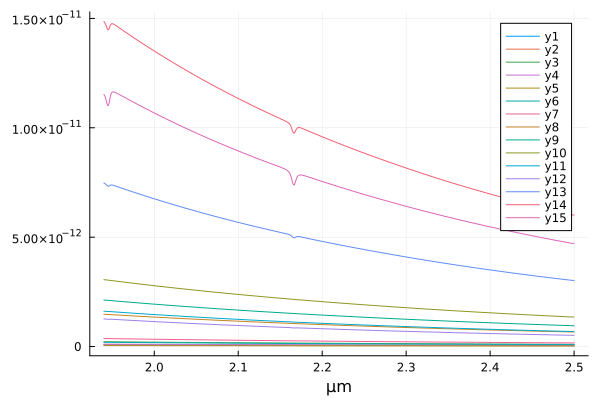

In [9]:
BeautyContest.@unpack_Instrument inst
attenuation = [ GaussianFunction(fiber_fwhm,sqrt((x* 1u"mas")^2 + (y*1u"mas")^2)) for (_,_,_,_,x,y) ∈ stars_table]

plot(λs.|>u"μm" ,attenuation.*flux, ticks=:native)

# Building the interferometric model

In [10]:

stars = ntuple(i->Punct([stars_table[i].x_pos*1u"mas",stars_table[i].y_pos*1u"mas"] , Interpolate(λs ,attenuation[i] .* flux[i])) , N);


# Computing the interferometric measurements

## Use ASPRO2 to determine (u,v)

In [11]:

filename = "data/Aspro2_47_Tuc_VLTI_GRAVITY_1.97-2.48-233ch_UT1-UT2-UT3-UT4_2026-09-22.fits"
oi = OIDataSet(filename);
tλ =  oi.vis2[1].eff_wave .* 1u"m"
Δλ = abs((-)(extrema(tλ)...)) / length(tλ) 

length(tλ) 

233

## Compute complex vis

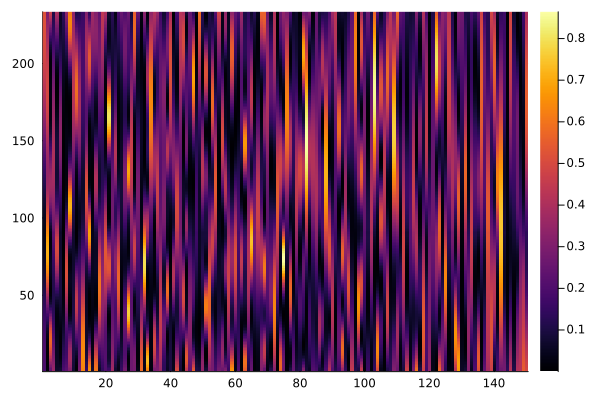

In [12]:
ucoord = oi.vis2[1].ucoord .* 1u"m"
vcoord = oi.vis2[1].vcoord .* 1u"m"

vis = make_vis(stars,ucoord,vcoord,tλ)
heatmap(abs2.(vis))

In [13]:
length(ucoord)

150

## Plot V2 in the (u,v) plane

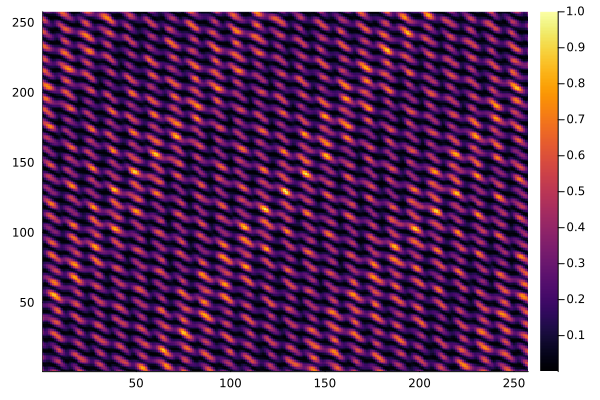

In [14]:
newvis2 = [ abs2.(get_vis(stars, u, v, tλ[1])) for u ∈ (-128:128)*1u"m" , v ∈ (-128:128)*1u"m" ]
heatmap(newvis2)

##  Comparing  Fourier transform of Complex Vis with the simulated image

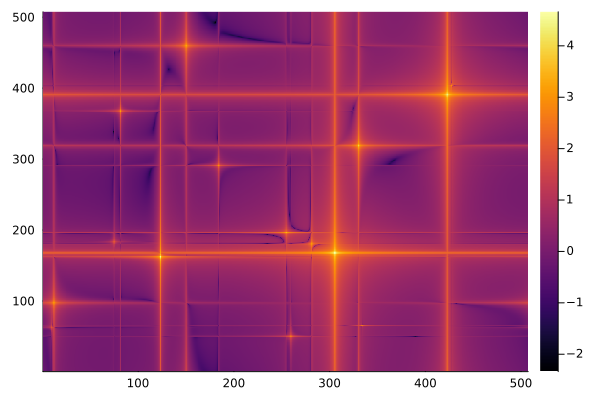

print device already activated


In [44]:
using FFTW
stp = upreferred(fov\oi.vis2[1].eff_wave[1].*1u"m")
imfov = 8*maximum(sqrt.(oi.vis2[1].ucoord.^2 .+ oi.vis2[1].vcoord.^2))*1u"m"
newvis = visgen(stars,  tλ[1], -imfov:stp:imfov)
heatmap(log10.(fftshift(abs.((fft(newvis))))))

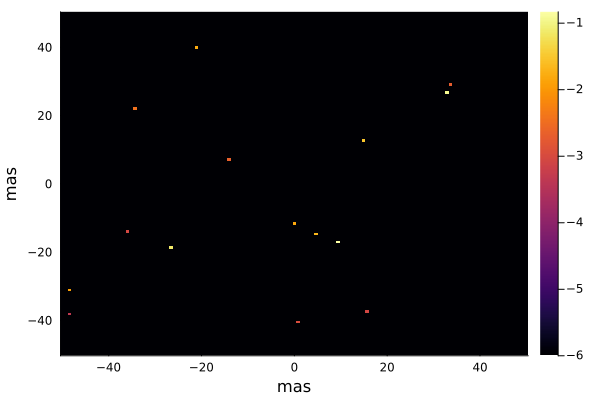

In [39]:
Npx =128
img = AxisArray(-6 .* ones(Float64,Npx+1,Npx+1), -fov/2:(fov)/Npx:fov/2 , -fov/2:(fov)/Npx: fov/2)
sf = mapreduce(f->f[1],+,flux)
foreach(i->img[atvalue.([stars_table[i].x_pos, stars_table[i].y_pos].*1u"mas"; atol = fov/Npx)...] .= log10(attenuation[i] .* flux[i][1]./sf), 1:N)
h = heatmap( -fov/2:(fov)/Npx:fov/2 , -fov/2:(fov)/Npx:fov/2 ,img)

## Average flux

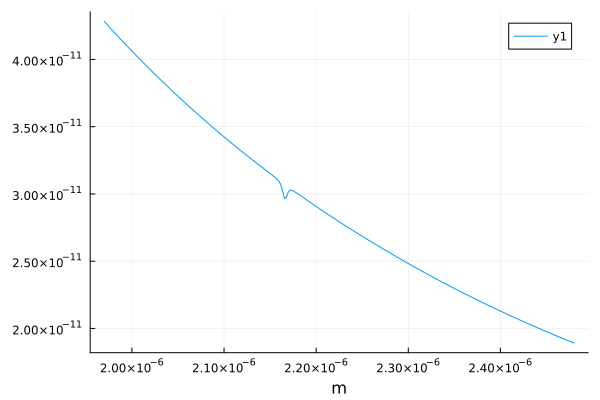

In [18]:
avgflux = map(λ -> get_flux(stars, λ), tλ);
plot(tλ,avgflux, ticks=:native)


## photon flux from the sky

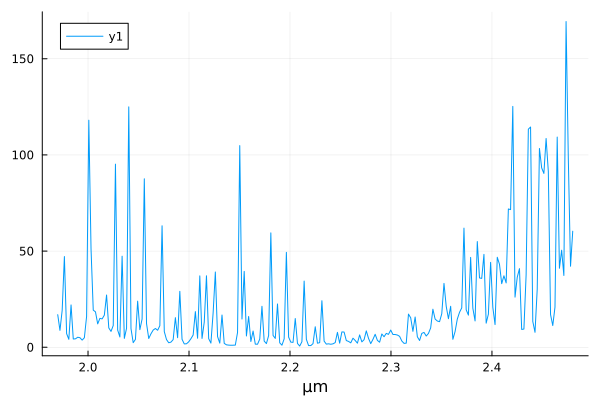

In [19]:
Ksky = 14.90u"arcsecond^-2"

skytablefile = "data/skytable.fits"
sky = readfits(skytablefile,ext=2)

Ssky = sky["FLUX"] .* 1u"s^-1/m^2/μm/arcsecond^2"
Tsky = sky["TRANS"]
Fsky = fluxtophoton(upreferred.(Ssky *  (π * (fiber_fwhm/2)^2)), inst,1) #  Tsky ?
plot(tλ.|>u"μm",Fsky, ticks=:native)

## Flux from the object for a single telescope

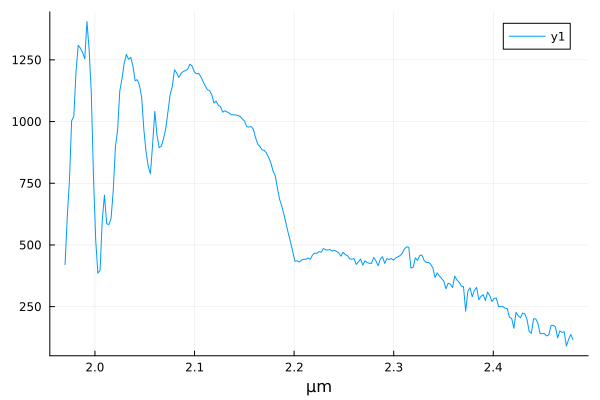

In [20]:
phflux = get_photonflux(Kmag, avgflux)
Fsc = fluxtophoton(SR* phflux, inst,Tsky)
plot(tλ.|>u"μm" , upreferred.(Fsc), ticks=:native)

In [21]:
Fbkg =  Fsky; ## background flux ( no laser here)

## Average number of photon per GRAVITY channel (in COMBINED)


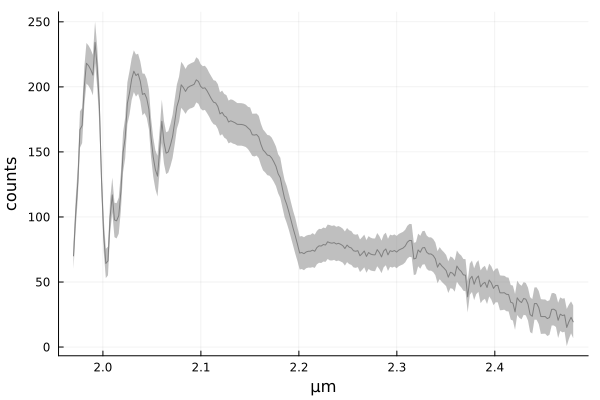

In [22]:
Fch = 2/12 .* Fsc
Varch = 2/12 .* (Fsc .+ 2 .* Fbkg) .+  2 .*  σch.^2 # (Fsc + Fbkg) - Fbkg per channel  
h=plot(tλ.|>u"μm" , Fch .± sqrt.(Varch); uncertainty_plot = :ribbon, ticks=:native, label=nothing, ylabel="counts", color=:gray)


In [23]:
#savefig(h, "AverageNumberPh.pdf")

## Calibrated flux estimation

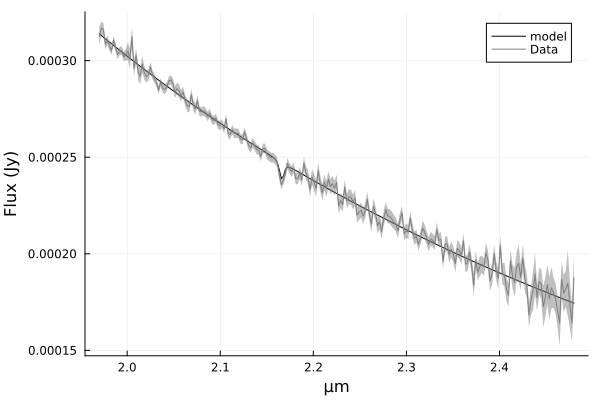

In [24]:
using StatsBase
Vflux = 1/(4 * NDIT) * ((Fsc .+ 2 .* Fbkg) .+  6 .* 2 .* σch.^2 )
Fflux = Fsc .± sqrt.(Vflux)
calibratedflux = photontoJansky(Fflux ./ SR, inst, tλ, Tsky)
plot(tλ.|>u"μm", Measurements.value.(calibratedflux) , ticks=:native,  label="model", ylabel="Flux", color=:black)
calibratedflux_data = Measurements.value.(calibratedflux) .+ Measurements.uncertainty.(calibratedflux) .* randn(size(calibratedflux)) 
h= plot!(tλ.|>u"μm", (calibratedflux_data .± Measurements.uncertainty.(calibratedflux) ) .|> u"μJy",uncertainty_plot = :ribbon, ticks=:native,  ylabel="Flux", color=:gray, label="Data")


In [37]:
#h= plot(tλ.|>u"μm", calibratedflux_data , uncertainty_plot = :ribbon, ticks=:native ,label=nothing, ylabel="Flux", color=:gray)
#savefig(h, "CalibratedFlux.pdf")

In [26]:
Krange = 13:190 # for 390nm in MED resolution
mean(calibratedflux[Krange])

0.00024297 ± 2.6e-7 Jy

## Correlated flux estimation

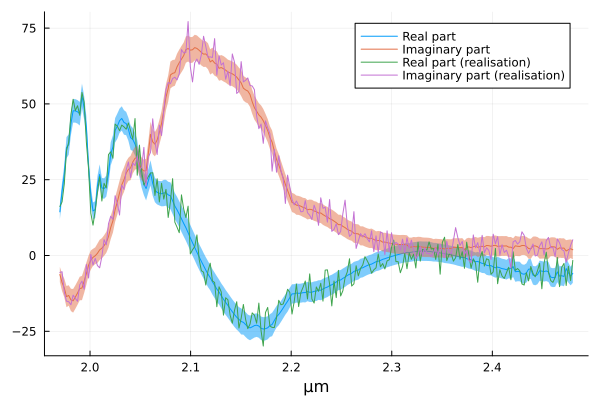

In [27]:
m1 = reshape(oi.vis[1].sta_index,2,6,25)[1,:,1]
m2 = reshape(oi.vis[1].sta_index,2,6,25)[2,:,1]
M = zeros(Int,6,4)
[ M[i,j] = 1 for (i,j) ∈ zip(1:6,m1)]
[ M[i,j] = -1 for (i,j) ∈ zip(1:6,m2)]

# Add random phase piston to visibilities
vispiston = vis .* reshape(cis.( M*randn(4,25)),1,:)

rvis = real.(vispiston) .* Fch ./ 2
rvisvar =   Varch ./ 4 ./ NDIT .* ones( size(rvis) )
 
ivis = imag.(vispiston) .*  Fch ./ 2
ivisvar =  Varch ./ 4 ./ NDIT .* ones( size(ivis) )

plot(tλ.|>u"μm",(rvis .± sqrt.(rvisvar))[:,20],uncertainty_plot = :ribbon, ticks=:native, label="Real part")
plot!(tλ.|>u"μm",(ivis .± sqrt.(ivisvar))[:,20], uncertainty_plot = :ribbon, ticks=:native, label="Imaginary part")

# provide a realisation 

rvisn = (rvis .+ sqrt.(rvisvar) .*randn(size(rvis))) #.± sqrt.(rvisvar)
ivisn = (ivis .+ sqrt.(ivisvar) .*randn(size(ivis))) #.± sqrt.(ivisvar)

plot!(tλ.|>u"μm", rvisn[:,20], ticks=:native, label="Real part (realisation)")
plot!(tλ.|>u"μm", ivisn[:,20], ticks=:native, label="Imaginary part (realisation)")

In [28]:
oi.vis[1].array.sta_name
oi.vis[1].sta_index
stname = oi.vis[1].array.sta_name[reshape(oi.vis[1].sta_index,2,6,25)[:,:,1]]
baselinename= ["$(stname[1,i])-$(stname[2,i])" for i ∈ Base.axes(stname,2)]

6-element Vector{String}:
 "UT1-UT2"
 "UT1-UT3"
 "UT1-UT4"
 "UT2-UT3"
 "UT2-UT4"
 "UT3-UT4"

## Squared visibilities estimation

###  V2 and its standard deviation estimation using Monte-Carlo

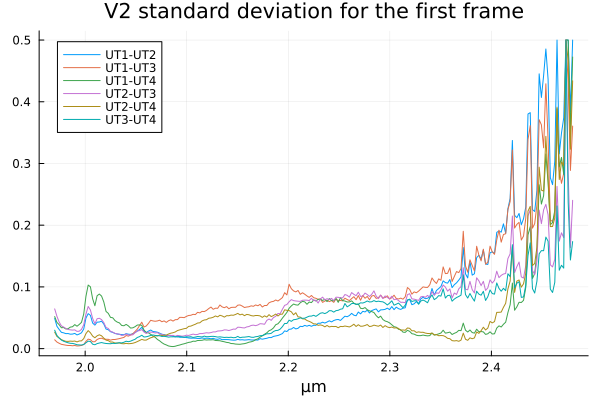

In [29]:
v2, v2err = make_V2(stars, ucoord, vcoord, tλ; Varch=Varch ./ NDIT,flux=Fch)
v2err = min.(v2err,0.5) #
plot(tλ.|>u"μm",v2err[:,1:6], title="V2 standard deviation for the first frame", label = hcat(baselinename...))


### Compute V2 correlation matrix from Kammerer 2020

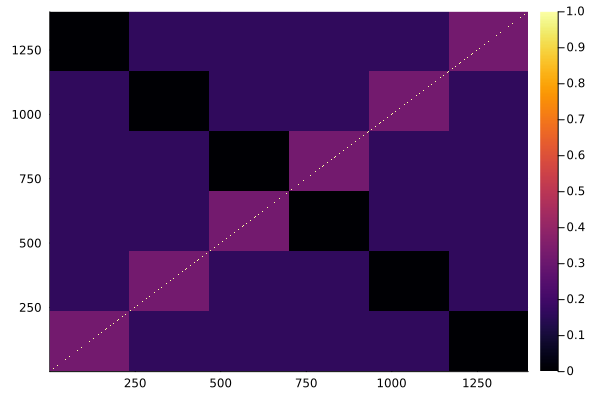

In [30]:
x = 0.32
Bsln = oi.vis2[1].sta_index[:,1:6]
V2corr = makeV2corr_Kammerer2020(Bsln, length(tλ), x)

heatmap(collect(V2corr))

### Computing a realisation

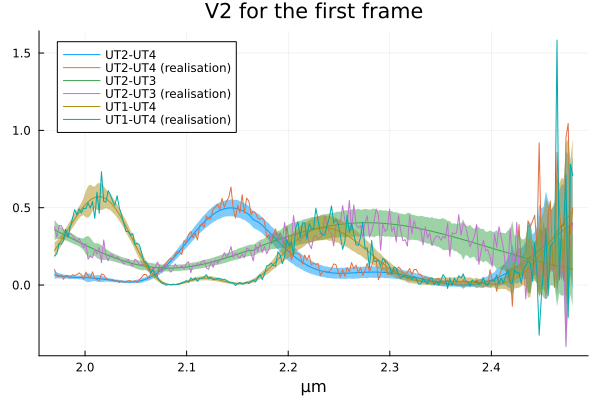

In [31]:
v2n = v2 .+ reshape(reshape(v2err,233*6,:) .* (sqrt(LinearAlgebra.Symmetric(V2corr)) *  randn(size(V2corr,1))),233,:);

plot(tλ.|>u"μm",(v2 .± v2err)[:,5], uncertainty_plot = :ribbon, ticks=:native, label="$(baselinename[5])", title="V2 for the first frame")
plot!(tλ.|>u"μm",v2n[:,5], label = "$(baselinename[5]) (realisation)")


plot!(tλ.|>u"μm",(v2 .± v2err)[:,4], uncertainty_plot = :ribbon, ticks=:native, label="$(baselinename[4])")
plot!(tλ.|>u"μm",v2n[:,4], label = "$(baselinename[4]) (realisation)")


plot!(tλ.|>u"μm",(v2 .± v2err)[:,3], uncertainty_plot = :ribbon, ticks=:native, label="$(baselinename[3])")
plot!(tλ.|>u"μm",v2n[:,3], label = "$(baselinename[3]) (realisation)")


## Closure phase estimation

###  Closure phase with  standard deviation estimation using Monte-Carlo

In [32]:

t3λ =  oi.t3[1].eff_wave .* 1u"m"

Δ3λ = abs((-)(extrema(t3λ)...)) / length(t3λ) 

u1coord = oi.t3[1].u1coord .* 1u"m"
v1coord = oi.t3[1].v1coord .* 1u"m"
u2coord = oi.t3[1].u2coord .* 1u"m"
v2coord = oi.t3[1].v2coord .* 1u"m"

t3phi, t3phierr = make_t3phi(stars, u1coord, v1coord, u2coord, v2coord, t3λ; Varch =Varch ./ NDIT, flux=(Fch));

### Compute T3phi correlation matrix from Kammerer 2020

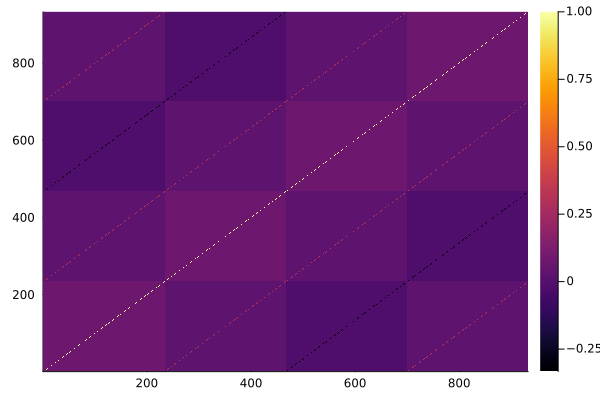

In [38]:
y = 7.4e-2
Trplt = oi.t3[1].sta_index[:,1:4]

T3corr = makeT3corr_Kammerer2020(Trplt,length(tλ), y);
heatmap(collect(T3corr))

In [34]:
stname = oi.t3[1].array.sta_name[reshape(oi.t3[1].sta_index,3,4,25)[:,:,1]]
T3name= ["$(stname[1,i])-$(stname[2,i])-$(stname[3,i])" for i ∈ Base.axes(stname,2)]

4-element Vector{String}:
 "UT1-UT2-UT3"
 "UT1-UT2-UT4"
 "UT1-UT3-UT4"
 "UT2-UT3-UT4"

### Compute a realization

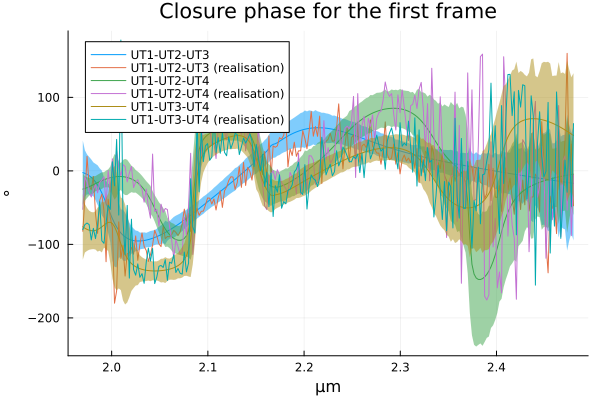

In [35]:
t3phin =  t3phi .+ reshape(reshape(t3phierr,233*4,25) .* (sqrt(LinearAlgebra.Symmetric(T3corr)) *  randn(size(T3corr,1))),233,:);

t3phin = rem.(t3phin, 360u"deg", RoundNearest) 

plot(tλ.|>u"μm",(t3phi.± t3phierr)[:,1], uncertainty_plot = :ribbon, ticks=:native, label="$(T3name[1])", title="Closure phase for the first frame")
plot!(tλ.|>u"μm",(t3phin)[:,1], label="$(T3name[1]) (realisation)")
plot!(tλ.|>u"μm",(t3phi.± t3phierr)[:,2], uncertainty_plot = :ribbon, ticks=:native, label="$(T3name[2])")
plot!(tλ.|>u"μm",(t3phin)[:,2], label="$(T3name[2]) (realisation)")
plot!(tλ.|>u"μm",(t3phi.± t3phierr)[:,3], uncertainty_plot = :ribbon, ticks=:native, label="$(T3name[3])")
plot!(tλ.|>u"μm",(t3phin)[:,3], label="$(T3name[3]) (realisation)")
#= plot!((t3phi.± t3phierr)[:,4], uncertainty_plot = :ribbon, ticks=:native)
plot!((t3phin)[:,4])
plot!((t3phi.± t3phierr)[:,5], uncertainty_plot = :ribbon, ticks=:native)
plot!((t3phin)[:,5])
plot!((t3phi.± t3phierr)[:,6], uncertainty_plot = :ribbon, ticks=:native)
plot!((t3phin)[:,6]) =#